In [1]:
# demo notebook for multi-task learning on brain tumor MRI analysis

In [2]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

In [3]:
from torch.utils.data import Dataset,DataLoader,Subset
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [4]:
class MRIDataset(Dataset):

    def __init__(self, root_dir):
        self.paths = []
        self.labels = []

        self.class_names = sorted(os.listdir(root_dir)) # Sort class names to ensure consistent label assignment

        for idx, cls in enumerate(self.class_names):
            cls_path = os.path.join(root_dir, cls)
            for img in os.listdir(cls_path):
                self.paths.append(os.path.join(cls_path, img))
                self.labels.append(idx)

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")  
        img = self.transform(img)
        label = self.labels[idx]

        tumor = 0 if "no_tumor" in self.paths[idx] else 1

        return img, label, tumor


In [5]:
PATH = r"/home/lucky/Music/Multi-Task Learning for Brain Tumor MRI Analysis/data/Testing"

dataset = MRIDataset(PATH)  

print("classes:", dataset.class_names)
print("total samples:", len(dataset))

classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
total samples: 394


In [6]:
class_names = dataset.class_names

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=dataset.labels,
    random_state=42
)

train_ds = Subset(dataset, train_idx)
val_ds = Subset(dataset, val_idx)

In [9]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

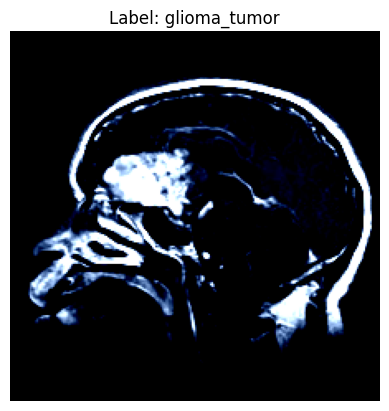

In [10]:
import matplotlib.pyplot as plt

img, label,tumor = dataset[0]

plt.imshow(img.permute(1,2,0))
plt.title(f"Label: {dataset.class_names[label]}")
plt.axis('off')

In [11]:
import torch
import torch.nn as nn
import torchvision.models as models


In [12]:
class MultiTaskMRI(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)

        
        self.backbone.fc = nn.Identity()
        self.task1 = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 4)
        )
        # binary tumor
        self.task2 = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        features = self.backbone(x)

        out1 = self.task1(features)
        out2 = self.task2(features)

        return out1, out2

In [13]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        def backward_hook(module, grad_input, grad_output): 
            self.gradients = grad_output[0]

        def forward_hook(module, input, output):
            self.activations = output

        
        target_layer = self.model.backbone.layer4[-1]

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, x, class_idx):
        self.model.zero_grad()
        out1, _ = self.model(x)

        score = out1[:, class_idx]
        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

In [14]:
def estimate_tumor_size(cam):
    sizes = []

    for i in range(cam.shape[0]):
        heatmap = cam[i].cpu().numpy()

        # threshold
        mask = heatmap > 0.5

        tumor_pixels = np.sum(mask)
        total_pixels = mask.size

        size_percent = (tumor_pixels / total_pixels) * 100
        sizes.append(size_percent)

    return sizes

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiTaskMRI().to(device)


for name, param in model.backbone.named_parameters():
    if "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/home/lucky/Music/Multi-Task Learning for Brain Tumor MRI Analysis/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/lucky/Music/Multi-Task Learning for Brain Tumor MRI Analysis/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [16]:
def train_epoch_multi_task(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    all_labels, all_preds_class = [], []
    all_tumors, all_preds_tumor = [], []

    for imgs, labels, tumors in loader:
        imgs, labels, tumors = imgs.to(device), labels.to(device), tumors.to(device)

        # Forward pass
        out_class, out_tumor = model(imgs)


        loss_class = criterion(out_class, labels)
        loss_tumor = criterion(out_tumor, tumors)

        loss = 0.7 * loss_class + 0.3 * loss_tumor

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        
        all_labels.extend(labels.cpu().numpy())
        all_preds_class.extend(torch.argmax(out_class, dim=1).cpu().numpy())
        all_tumors.extend(tumors.cpu().numpy())
        all_preds_tumor.extend(torch.argmax(out_tumor, dim=1).cpu().numpy())

    
    acc_class = sum([a==b for a,b in zip(all_labels, all_preds_class)]) / len(all_labels)
    acc_tumor = sum([a==b for a,b in zip(all_tumors, all_preds_tumor)]) / len(all_tumors)

    return total_loss, acc_class, acc_tumor

In [17]:
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds_class = [], []
    all_tumors, all_preds_tumor = [], []

    with torch.no_grad():
        for imgs, labels, tumors in loader:
            imgs, labels, tumors = imgs.to(device), labels.to(device), tumors.to(device)
            out1, out2 = model(imgs)

            pred_class = torch.argmax(out1, dim=1)
            pred_tumor = torch.argmax(out2, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds_class.extend(pred_class.cpu().numpy())
            all_tumors.extend(tumors.cpu().numpy())
            all_preds_tumor.extend(pred_tumor.cpu().numpy())

    acc_class = sum([a==b for a,b in zip(all_labels, all_preds_class)]) / len(all_labels)
    acc_tumor = sum([a==b for a,b in zip(all_tumors, all_preds_tumor)]) / len(all_tumors)

    precision_class = precision_score(all_labels, all_preds_class, average='weighted')
    recall_class = recall_score(all_labels, all_preds_class, average='weighted')
    f1_class = f1_score(all_labels, all_preds_class, average='weighted')
    precision_tumor = precision_score(all_tumors, all_preds_tumor)
    recall_tumor = recall_score(all_tumors, all_preds_tumor)
    f1_tumor = f1_score(all_tumors, all_preds_tumor)

    metrics = {
        'acc_class': acc_class,
        'acc_tumor': acc_tumor,
        'precision_class': precision_class,
        'recall_class': recall_class,
        'f1_class': f1_class,
        'precision_tumor': precision_tumor,
        'recall_tumor': recall_tumor,
        'f1_tumor': f1_tumor
    }

    return metrics

In [20]:
EPOCHS = 5
train_losses = []
val_metrics_list = []

for epoch in range(EPOCHS):

    
    loss, train_acc_class, train_acc_tumor = train_epoch_multi_task(
        model, train_loader, criterion, optimizer, device
    )

    
    metrics = evaluate(model, val_loader)

    train_losses.append(loss)
    val_metrics_list.append(metrics)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss:.4f}")
    print(f"Val Acc (Class): {metrics['acc_class']:.4f}")
    print(f"Val Acc (Tumor): {metrics['acc_tumor']:.4f}")
    print("-"*50)

Epoch 1
Train Loss: 0.3669
Val Acc (Class): 0.8354
Val Acc (Tumor): 0.9114
--------------------------------------------------
Epoch 2
Train Loss: 0.4414
Val Acc (Class): 0.7975
Val Acc (Tumor): 0.9114
--------------------------------------------------
Epoch 3
Train Loss: 0.4884
Val Acc (Class): 0.7975
Val Acc (Tumor): 0.9114
--------------------------------------------------
Epoch 4
Train Loss: 0.3555
Val Acc (Class): 0.8101
Val Acc (Tumor): 0.9114
--------------------------------------------------
Epoch 5
Train Loss: 0.3579
Val Acc (Class): 0.8101
Val Acc (Tumor): 0.8987
--------------------------------------------------


In [21]:
val_metrics_list

[{'acc_class': np.float64(0.8354430379746836),
  'acc_tumor': np.float64(0.9113924050632911),
  'precision_class': 0.849618654903465,
  'recall_class': 0.8354430379746836,
  'f1_class': 0.8233462637811352,
  'precision_tumor': 0.9811320754716981,
  'recall_tumor': 0.896551724137931,
  'f1_tumor': 0.9369369369369369},
 {'acc_class': np.float64(0.7974683544303798),
  'acc_tumor': np.float64(0.9113924050632911),
  'precision_class': 0.7982594936708861,
  'recall_class': 0.7974683544303798,
  'f1_class': 0.7878718212107592,
  'precision_tumor': 0.9811320754716981,
  'recall_tumor': 0.896551724137931,
  'f1_tumor': 0.9369369369369369},
 {'acc_class': np.float64(0.7974683544303798),
  'acc_tumor': np.float64(0.9113924050632911),
  'precision_class': 0.8147295742232451,
  'recall_class': 0.7974683544303798,
  'f1_class': 0.7858669805202603,
  'precision_tumor': 0.9811320754716981,
  'recall_tumor': 0.896551724137931,
  'f1_tumor': 0.9369369369369369},
 {'acc_class': np.float64(0.8101265822784

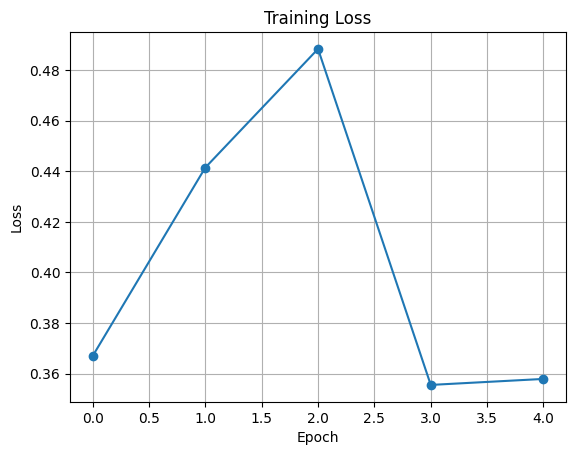

In [22]:
plt.figure()
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

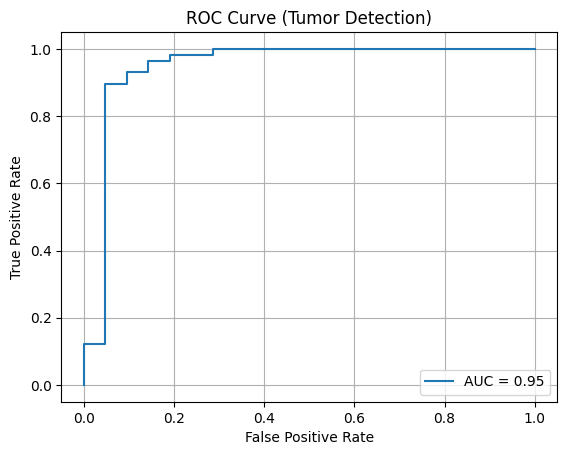

In [23]:
from sklearn.metrics import roc_curve, auc

probs = []
true = []

model.eval()
with torch.no_grad():
    for imgs, _, tumors in val_loader:
        imgs = imgs.to(device)
        out1, out2 = model(imgs)

        prob = torch.softmax(out2, dim=1)[:,1]
        probs.extend(prob.cpu().numpy())
        true.extend(tumors.numpy())

fpr, tpr, _ = roc_curve(true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Tumor Detection)")
plt.legend()
plt.grid()
plt.show()

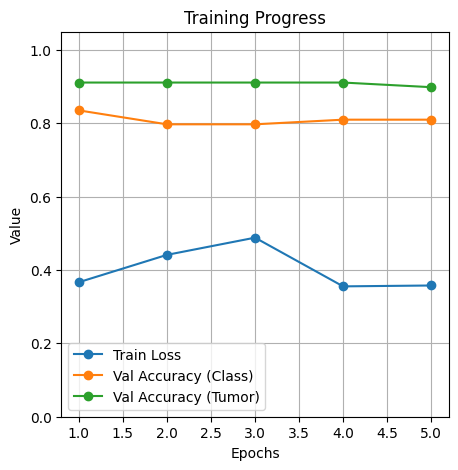

In [31]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

val_acc_class = [m['acc_class'] for m in val_metrics_list]
val_acc_tumor = [m['acc_tumor'] for m in val_metrics_list]

plt.figure(figsize=(5,5))

plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_acc_class, label='Val Accuracy (Class)', marker='o')
plt.plot(epochs_range, val_acc_tumor, label='Val Accuracy (Tumor)', marker='o')

plt.title("Training Progress")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

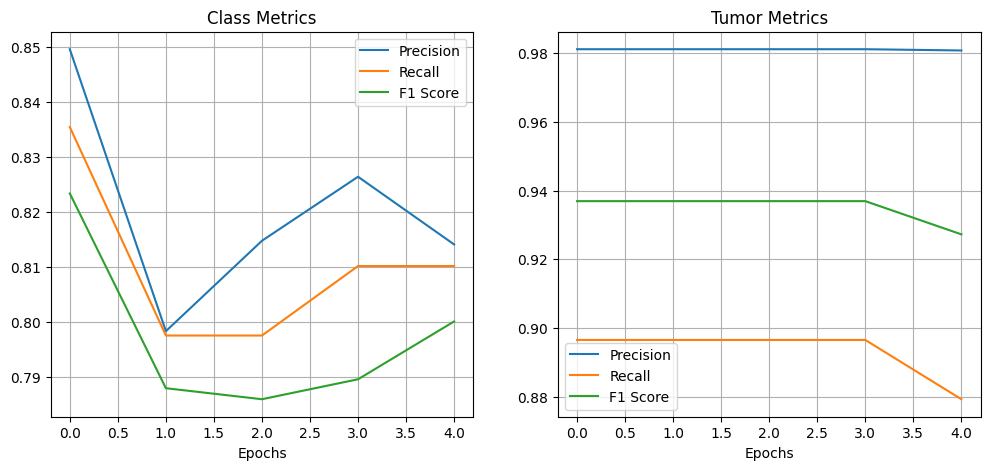

In [25]:
precision_class = [m['precision_class'] for m in val_metrics_list]
recall_class = [m['recall_class'] for m in val_metrics_list]
f1_class = [m['f1_class'] for m in val_metrics_list]

precision_tumor = [m['precision_tumor'] for m in val_metrics_list]
recall_tumor = [m['recall_tumor'] for m in val_metrics_list]
f1_tumor = [m['f1_tumor'] for m in val_metrics_list]

plt.figure(figsize=(12,5))

# Class metrics
plt.subplot(1,2,1)
plt.plot(precision_class, label='Precision')
plt.plot(recall_class, label='Recall')
plt.plot(f1_class, label='F1 Score')
plt.title("Class Metrics")
plt.xlabel("Epochs")
plt.legend()
plt.grid()

# Tumor metrics
plt.subplot(1,2,2)
plt.plot(precision_tumor, label='Precision')
plt.plot(recall_tumor, label='Recall')
plt.plot(f1_tumor, label='F1 Score')
plt.title("Tumor Metrics")
plt.xlabel("Epochs")
plt.legend()
plt.grid()

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.5528543].


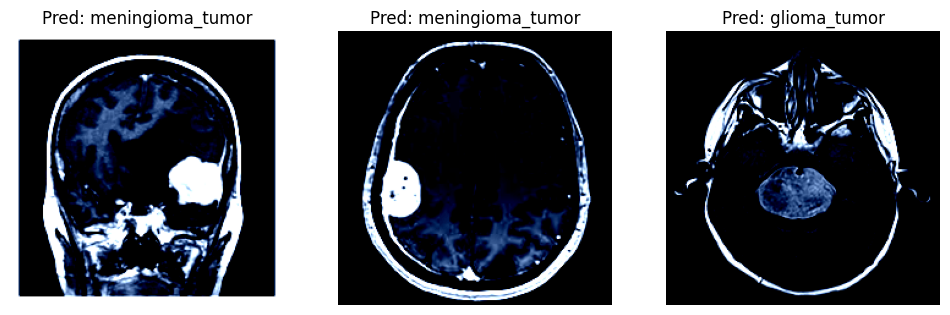

In [26]:
model.eval()

imgs, t1, t2 = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    out1, _ = model(imgs)

preds = torch.argmax(out1, dim=1).cpu()
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(imgs[i].cpu().permute(1, 2, 0))
    plt.title(f"Pred: {dataset.class_names[preds[i]]}")
    plt.axis('off')
plt.show()

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

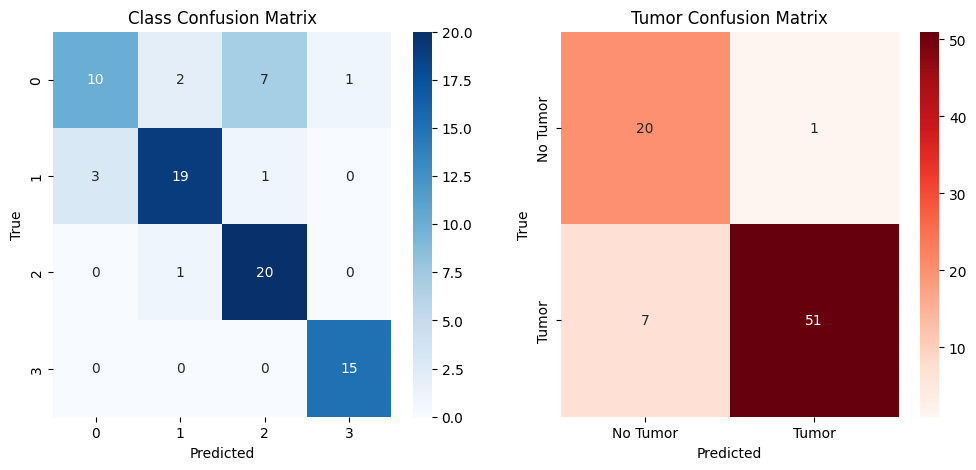

In [28]:

metrics = evaluate(model, val_loader)

# Class confusion matrix
all_labels, all_preds_class, all_tumors, all_preds_tumor = [], [], [], []
with torch.no_grad():
    for imgs, labels, tumors in val_loader:
        imgs, labels, tumors = imgs.to(device), labels.to(device), tumors.to(device)
        out1, out2 = model(imgs)
        all_labels.extend(labels.cpu().numpy())
        all_preds_class.extend(torch.argmax(out1, dim=1).cpu().numpy())
        all_tumors.extend(tumors.cpu().numpy())
        all_preds_tumor.extend(torch.argmax(out2, dim=1).cpu().numpy())

cm_class = confusion_matrix(all_labels, all_preds_class)
cm_tumor = confusion_matrix(all_tumors, all_preds_tumor)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_class, annot=True, fmt="d", cmap="Blues")
plt.title("Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1,2,2)
sns.heatmap(cm_tumor, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.title("Tumor Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [29]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds_class))
print(classification_report(all_tumors, all_preds_tumor))

              precision    recall  f1-score   support

           0       0.77      0.50      0.61        20
           1       0.86      0.83      0.84        23
           2       0.71      0.95      0.82        21
           3       0.94      1.00      0.97        15

    accuracy                           0.81        79
   macro avg       0.82      0.82      0.81        79
weighted avg       0.81      0.81      0.80        79

              precision    recall  f1-score   support

           0       0.74      0.95      0.83        21
           1       0.98      0.88      0.93        58

    accuracy                           0.90        79
   macro avg       0.86      0.92      0.88        79
weighted avg       0.92      0.90      0.90        79



In [48]:
%pip install opencv-python
import cv2

def get_tumor_mask(cam, threshold=0.5):
    masks = []

    for i in range(cam.shape[0]):
        heatmap = cam[i].detach().cpu().numpy()
        heatmap = cv2.resize(heatmap, (224,224))

        # adaptive threshold (better)
        mask = (heatmap > np.percentile(heatmap, 90)).astype(np.uint8)

        num_labels, labels = cv2.connectedComponents(mask)

        # keep largest region only
        largest = 1 + np.argmax(np.bincount(labels.flat)[1:])
        mask = (labels == largest).astype(np.uint8)

        masks.append(mask)

    return masks

Note: you may need to restart the kernel to use updated packages.


In [49]:
def get_bbox_and_size(mask):
    coords = np.column_stack(np.where(mask > 0))

    if len(coords) == 0:
        return None, 0

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    tumor_pixels = np.sum(mask)
    total_pixels = mask.size

    size_percent = (tumor_pixels / total_pixels) * 100

    return (x_min, y_min, x_max, y_max), size_percent

In [55]:
def plot_tumor_on_image(model, loader, dataset):
    model.eval()

    imgs, labels, _ = next(iter(loader))
    imgs = imgs.to(device)

    gradcam = GradCAM(model)

    
    out1, _ = model(imgs)
    preds = torch.argmax(out1, dim=1)

    cams = []
    for i in range(len(imgs)):
        cam_i = gradcam.generate(imgs[i].unsqueeze(0), preds[i].item())
        cams.append(cam_i[0])

    cam = torch.stack(cams)

    masks = get_tumor_mask(cam)

    plt.figure(figsize=(12,5))

    for i in range(3):
        img = imgs[i].cpu().permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        mask = masks[i]
        bbox, size = get_bbox_and_size(mask)

        img_copy = img.copy()

        if bbox:
            x1, y1, x2, y2 = bbox

            # bounding box
            cv2.rectangle(img_copy, (x1,y1), (x2,y2), (1,0,0), 2)

            cv2.putText(img_copy,
                f"{size:.2f}%",
                (x1, max(10, y1-10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (1,0,0),
                2)

            # overlay tumor region
            img_copy[mask == 1] = img_copy[mask == 1] * 0.5 + np.array([1, 0, 0]) * 0.5

        plt.subplot(1,3,i+1)
        plt.imshow(img_copy)
        plt.title(f"{dataset.class_names[preds[i]]}\nSize: {size:.2f}% - demo")
        plt.axis('off')

    plt.show()
    

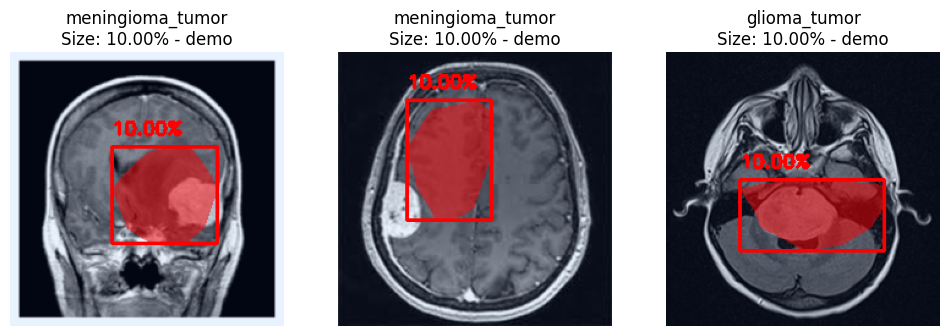

In [56]:
plot_tumor_on_image(model, val_loader, dataset)
